# Phân loại bệnh tim: Decision Tree, Random Forest và XGBoost


In [2]:
#Tải file heart.csv từ trên máy tính lên colab
from google.colab import files
uploaded = files.upload()
DATA_PATH = next(iter(uploaded))
print('Đã upload:', DATA_PATH)

Saving heart.csv to heart.csv
Đã upload: heart.csv


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu:', df.shape)
df.head()

Kích thước dữ liệu: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.info()
print('\nSố giá trị thiếu mỗi cột:')
display(df.isna().sum())
print('\nTỷ lệ nhãn HeartDisease:')
display(df['HeartDisease'].value_counts(normalize=True).rename('Tỷ lệ'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Số giá trị thiếu mỗi cột:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



Tỷ lệ nhãn HeartDisease:


,Tỷ lệ
HeartDisease,
1,0.553377
0,0.446623


In [27]:
# Tách X/y và chia dữ liệu: 80% train, 20% test
X = df.drop(columns='HeartDisease')
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)
# Random_state là tham số trong hàm chia bộ test, đóng vai trò làm seed để chia ngẫu nhiên.
# Điều này đảm bảo kết quả các lần chạy lại notebook ko có sự khác nhau, đảm bảo tính ổn định.

categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numeric_cols = X.select_dtypes(exclude=['object', 'string']).columns

#Quy tắc tiền xử lí dữ liệu, cột categorical thì chuyển thành các feature one-hot 1 0
#Cột nào là số sẵn thì bỏ qua ko xử lí, passthrough
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])
X_train_ready = preprocessor.fit_transform(X_train) #Tiền xử lí tập train
#Fit trong preprocessing nghĩa là one-hot và tính mean, std, chuẩn hóa z-score
# chỉ bằng các dữ liệu ở tập train. xong dùng lại nó để transform tập train và test.
X_test_ready = preprocessor.transform(X_test) #Transform tập test = dữ liệu one-hot train.
feature_names = preprocessor.get_feature_names_out()
#Lưu lại ý nghĩa của các cột trong data feed cho mô hình, vì sau khi transform data.
#đã bị biến thành numpy array.

print('Train:', X_train_ready.shape, '| Test:', X_test_ready.shape)
results = {}

Train: (734, 20) | Test: (184, 20)


In [28]:
#Viết hàm để vừa train, vừa đo thời gian train, vừa đánh giá model.
def evaluate_model(name, model):
    start = time.perf_counter()
    model.fit(X_train_ready, y_train)
    train_time = time.perf_counter() - start

    train_acc = accuracy_score(y_train, model.predict(X_train_ready))
    test_acc = accuracy_score(y_test, model.predict(X_test_ready))
    results[name] = {
        'Train accuracy': train_acc,
        'Test accuracy': test_acc,
        'Chênh lệch train-test': train_acc - test_acc,
        'Thời gian train (giây)': train_time
    }
    print(f'Train accuracy: {train_acc:.3f}')
    print(f'Test accuracy:  {test_acc:.3f}')
    print(f'Chênh lệch:     {train_acc - test_acc:.3f}')
    print(f'Thời gian train: {train_time:.3f} giây')
    return model

def plot_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    #Lấy danh sách các feature importances từ model và biến thành pd series.
    importance = importance.sort_values().tail(12)
    ax = importance.plot.barh(figsize=(8, 5), color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Feature importance')
    plt.show()
    print('Feature quan trọng nhất:', importance.index[-1])

## 1. Decision Tree

Train accuracy: 1.000
Test accuracy:  0.815
Chênh lệch:     0.185
Thời gian train: 0.013 giây


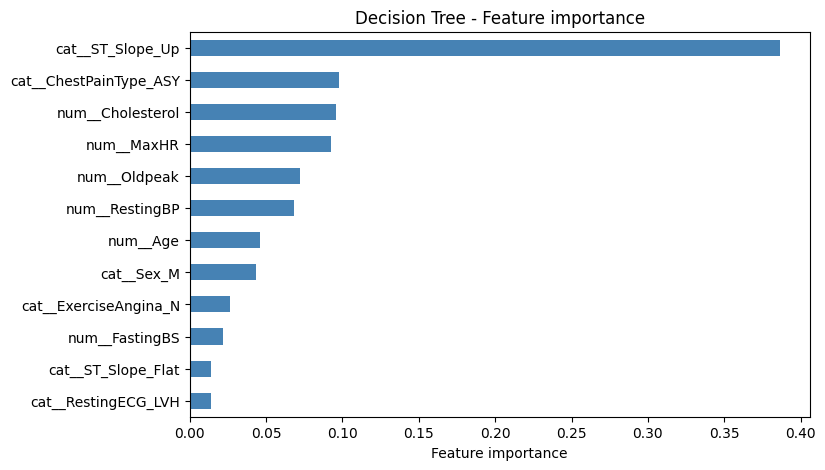

Feature quan trọng nhất: cat__ST_Slope_Up


In [31]:
#Khởi tạo model decision tree với seed 67 để đảm bảo tính ổn định mỗi lần train.
decision_tree = DecisionTreeClassifier(random_state=67)
#Dùng hàm evaluate model vừa viết ở trên, vừa fit, vừa tính accuracy và time.
decision_tree = evaluate_model('Decision Tree', decision_tree)
#Dùng hàm plot để vẽ kết quả từ model đã học được.
plot_importance(decision_tree, 'Decision Tree - Feature importance')

Nhận thấy accuracy là 1, model đang có dấu hiệu bị over-fit. Thử triển khai thêm các siêu tham số cho mô hình để giảm overfit và tăng acc ở tập test.

Bằng cách giới hạn max_depth và tăng min_samples_leaf, chúng ta ép mô hình phải học các quy luật tổng quát thay vì học thuộc lòng với độ sâu cây vô hạn.

Train accuracy: 0.866
Test accuracy:  0.864
Chênh lệch:     0.002
Thời gian train: 0.004 giây


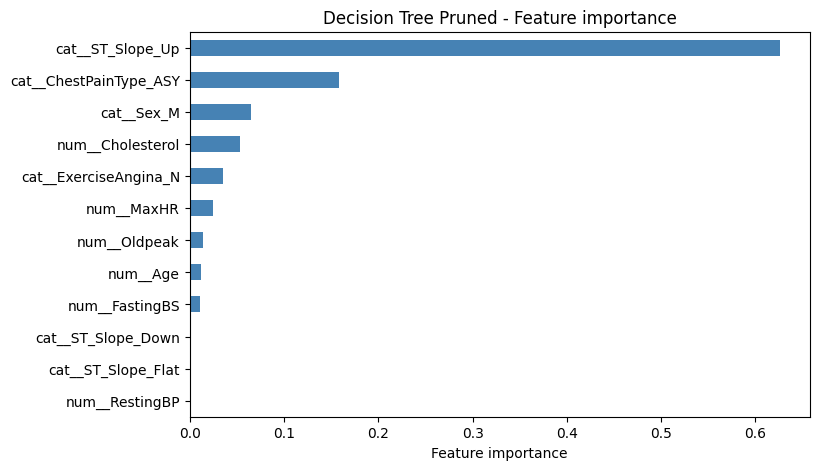

Feature quan trọng nhất: cat__ST_Slope_Up


In [30]:
dt_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=67)
dt_pruned = evaluate_model('Decision Tree (Pruned)', dt_pruned)
plot_importance(dt_pruned, 'Decision Tree Pruned - Feature importance')

#Max depth là độ sâu tối đa của cây.
#Min samples leaf là số lượng mẫu tối thiểu ở mỗi lá để tránh học thuộc lòng nhiễu dữ liệu.

## 2. Random Forest

Train accuracy: 1.000
Test accuracy:  0.886
Chênh lệch:     0.114
Thời gian train: 0.501 giây


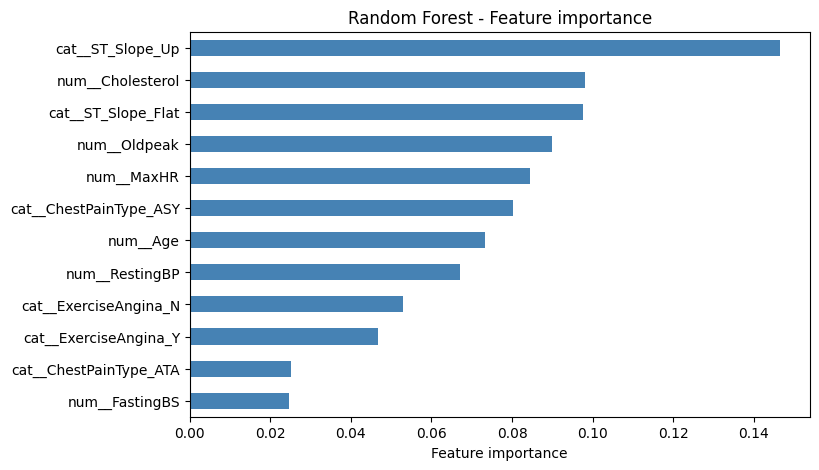

Feature quan trọng nhất: cat__ST_Slope_Up


In [32]:
random_forest = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)
random_forest = evaluate_model('Random Forest', random_forest)
plot_importance(random_forest, 'Random Forest - Feature importance')

### Cải tiến Random Forest (Pruning)
Chúng ta giới hạn độ sâu và số lượng mẫu tại lá để mô hình bền vững hơn với dữ liệu mới.

Train accuracy: 0.902
Test accuracy:  0.875
Chênh lệch:     0.027
Thời gian train: 2.388 giây


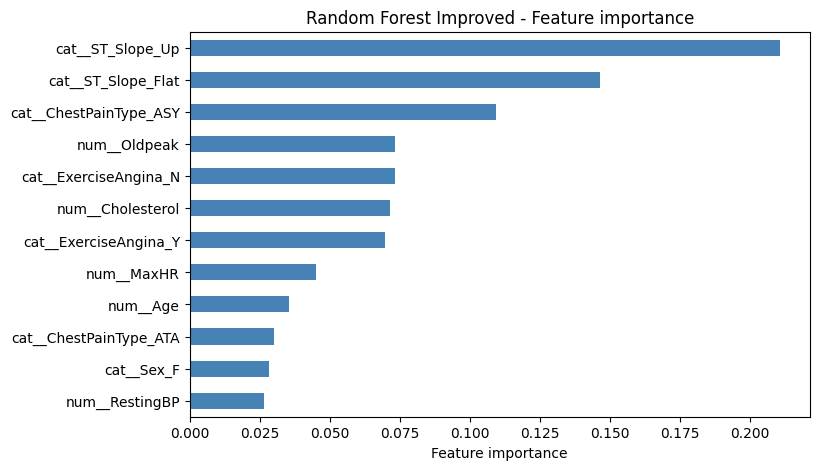

Feature quan trọng nhất: cat__ST_Slope_Up


In [38]:
rf_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
#n_estimators: số lượng cây trong rừng.
#max_features='sqrt': mỗi lần chia nhánh chỉ lấy ngẫu nhiên căn bậc hai số lượng feature để đảm bảo tính đa dạng
#Ưu điểm: tăng tính đa dạng của các cây trong rừng, tránh lặp nhiều cây y hệt nhau.
#n_jobs: sử dụng tối đa số nhân cpu để xử lí.
rf_improved = evaluate_model('Random Forest (Improved)', rf_improved)
plot_importance(rf_improved, 'Random Forest Improved - Feature importance')

Hãy chạy lại cell tổng kết cuối cùng để xem thứ hạng các mô hình thay đổi như thế nào.

### 3, XGBoost


Train accuracy: 1.000
Test accuracy:  0.859
Chênh lệch:     0.141
Thời gian train: 0.125 giây


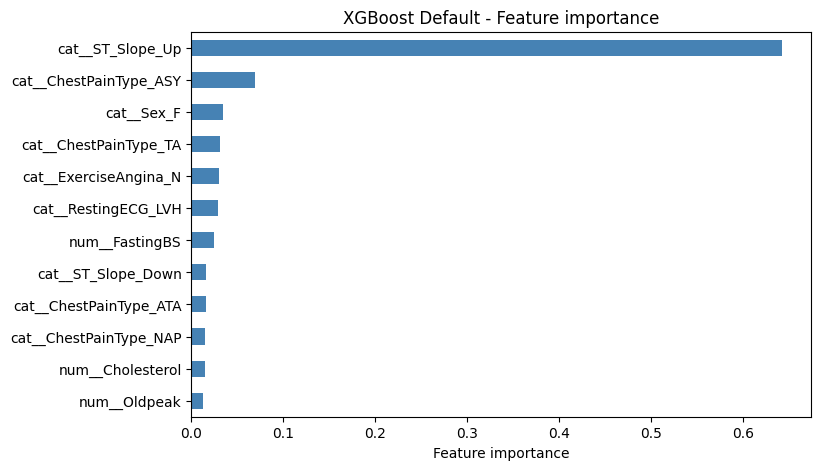

Feature quan trọng nhất: cat__ST_Slope_Up


In [43]:
xgb_default = XGBClassifier(random_state=67)
xgb_default = evaluate_model('XGBoost (Default)', xgb_default)
plot_importance(xgb_default, 'XGBoost Default - Feature importance')

XGBoost được cải tiến, truyền siêu tham số

Train accuracy: 0.946
Test accuracy:  0.875
Chênh lệch:     0.071
Thời gian train: 0.060 giây


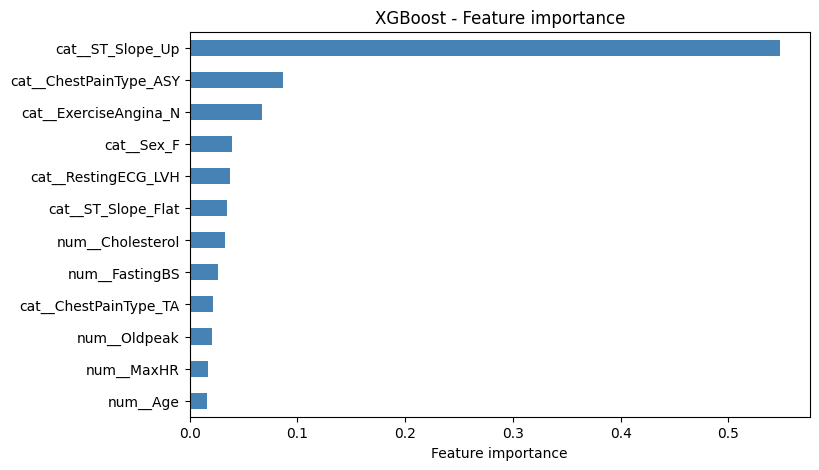

Feature quan trọng nhất: cat__ST_Slope_Up


In [45]:
xgboost = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgboost = evaluate_model('XGBoost', xgboost)
plot_importance(xgboost, 'XGBoost - Feature importance')

## Bảng tổng kết và nhận xét

In [46]:
# Cập nhật danh sách mô hình đầy đủ bao gồm cả bản mặc định
models['Random Forest (Improved)'] = rf_improved
models['XGBoost (Default)'] = xgb_default

# Tạo bảng tổng kết từ dictionary kết quả
summary = pd.DataFrame(results).T

# Hiển thị bảng với định dạng số đẹp
print("BẢNG TỔNG KẾT HIỆU NĂNG CÁC MÔ HÌNH:")
display(summary.style.format({
    'Train accuracy': '{:.3f}',
    'Test accuracy': '{:.3f}',
    'Chênh lệch train-test': '{:.3f}',
    'Thời gian train (giây)': '{:.3f}'
}))

# So sánh feature quan trọng nhất của các mô hình
top_features = {
    name: feature_names[np.argmax(model.feature_importances_)]
    for name, model in models.items()
}
print("\nFEATURE QUAN TRỌNG NHẤT THEO TỪNG MÔ HÌNH:")
display(pd.Series(top_features, name='Feature quan trọng nhất'))

BẢNG TỔNG KẾT HIỆU NĂNG CÁC MÔ HÌNH:


,Train accuracy,Test accuracy,Chênh lệch train-test,Thời gian train (giây)
Decision Tree (Pruned),0.866,0.864,0.002,0.004
Decision Tree,1.000,0.815,0.185,0.013
Random Forest,1.000,0.886,0.114,0.501
Random Forest (Improved),0.902,0.875,0.027,2.388
XGBoost,0.946,0.875,0.071,0.060
XGBoost (Default),1.000,0.859,0.141,0.125



FEATURE QUAN TRỌNG NHẤT THEO TỪNG MÔ HÌNH:


,Feature quan trọng nhất
Decision Tree,cat__ST_Slope_Up
Random Forest,cat__ST_Slope_Up
XGBoost,cat__ST_Slope_Up
Decision Tree (Pruned),cat__ST_Slope_Up
Random Forest (Improved),cat__ST_Slope_Up
XGBoost (Default),cat__ST_Slope_Up
